<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

import sqlite3

conn = sqlite3.connect('/resources/DA0321EN/lab/module4/survey-data.sqlite')



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




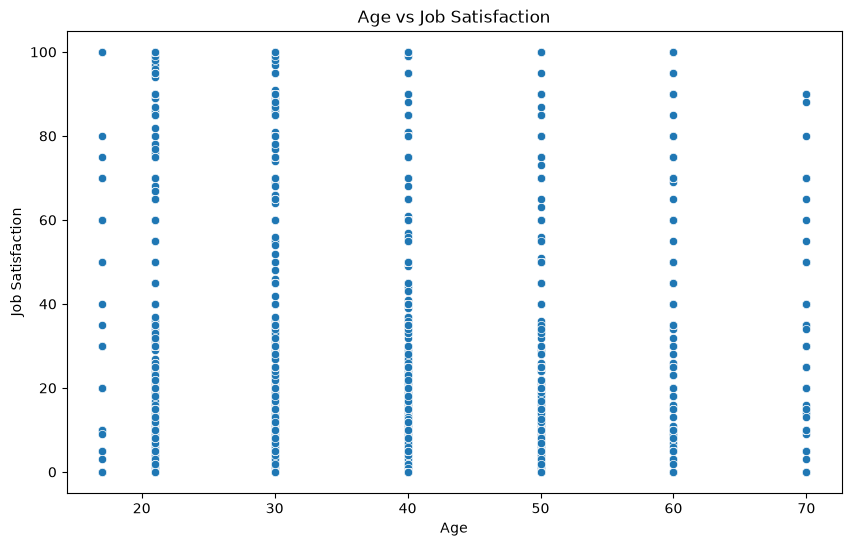

In [7]:
QUERY = """
SELECT Age, JobSatPoints_6
FROM main
WHERE Age IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_age_jobsat = pd.read_sql_query(QUERY, conn)

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Age categories to numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_age_jobsat['AgeNumeric'] = df_age_jobsat['Age'].map(age_mapping)

# Remove null values
df_age_jobsat = df_age_jobsat.dropna(subset=['AgeNumeric'])

# Scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_age_jobsat,
    x='AgeNumeric',
    y='JobSatPoints_6'
)

plt.title('Age vs Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')

plt.show()


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


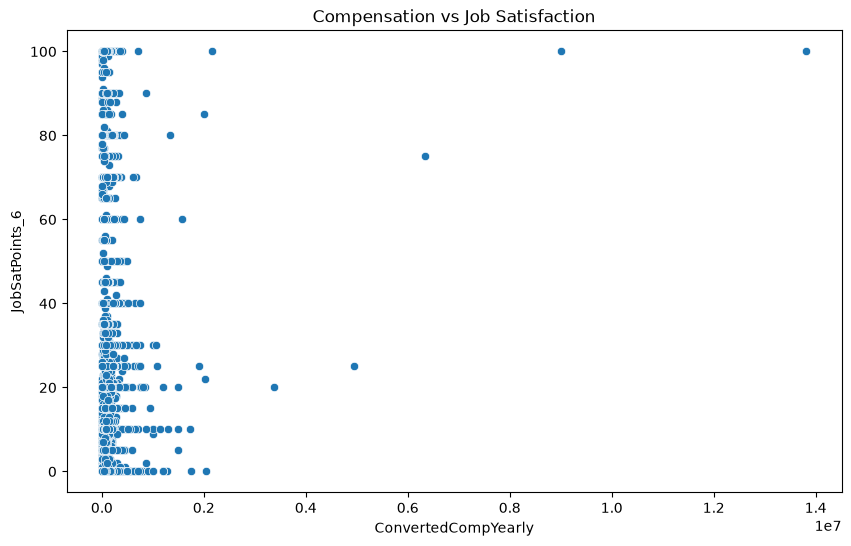

In [8]:
QUERY = """
SELECT ConvertedCompYearly, JobSatPoints_6
FROM main
WHERE ConvertedCompYearly IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_comp_jobsat = pd.read_sql_query(QUERY, conn)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_comp_jobsat,
    x='ConvertedCompYearly',
    y='JobSatPoints_6'
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_6')

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


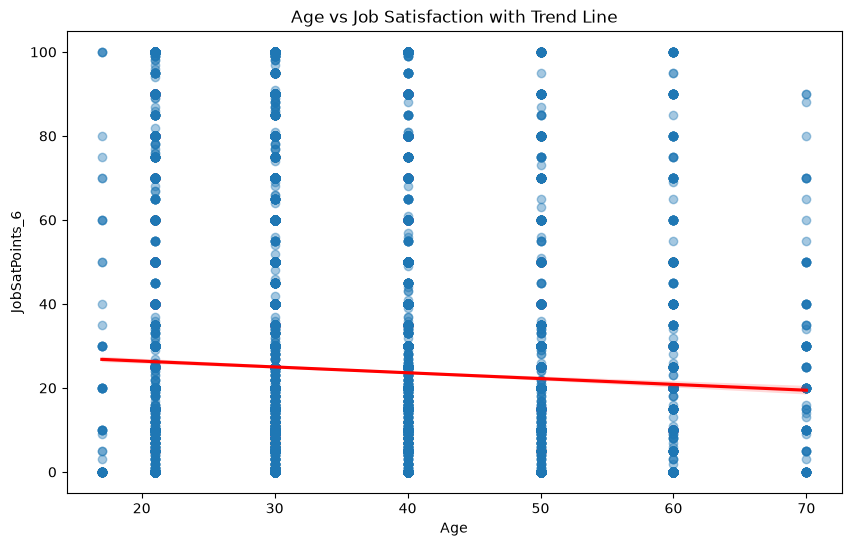

In [9]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_age_jobsat,
    x='AgeNumeric',
    y='JobSatPoints_6',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('Age vs Job Satisfaction with Trend Line')
plt.xlabel('Age')
plt.ylabel('JobSatPoints_6')

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


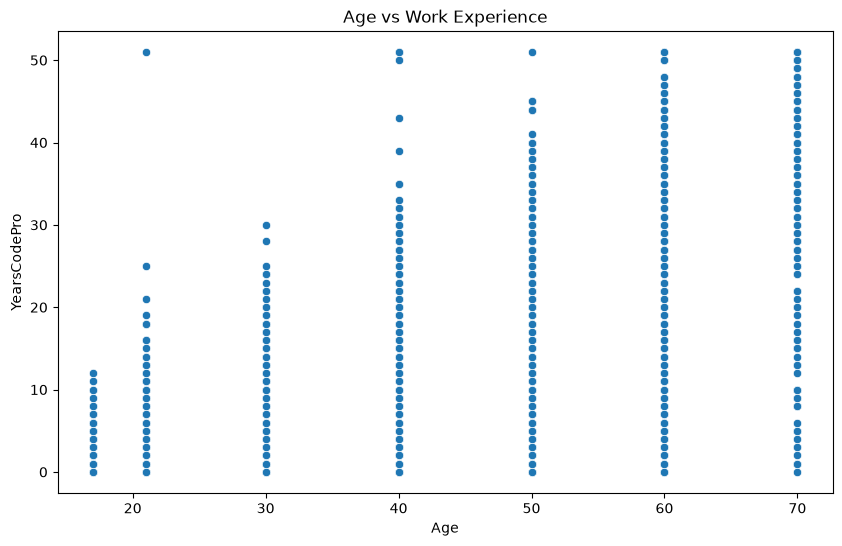

In [10]:
QUERY = """
SELECT Age, YearsCodePro
FROM main
WHERE Age IS NOT NULL
AND YearsCodePro IS NOT NULL
"""

df_age_exp = pd.read_sql_query(QUERY, conn)

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_age_exp['AgeNumeric'] = df_age_exp['Age'].map(age_mapping)

df_age_exp['YearsCodePro'] = df_age_exp['YearsCodePro'].replace({
    'Less than 1 year': '0',
    'More than 50 years': '51'
})

df_age_exp['YearsCodePro'] = pd.to_numeric(
    df_age_exp['YearsCodePro'],
    errors='coerce'
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_age_exp,
    x='AgeNumeric',
    y='YearsCodePro'
)

plt.title('Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('YearsCodePro')

plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


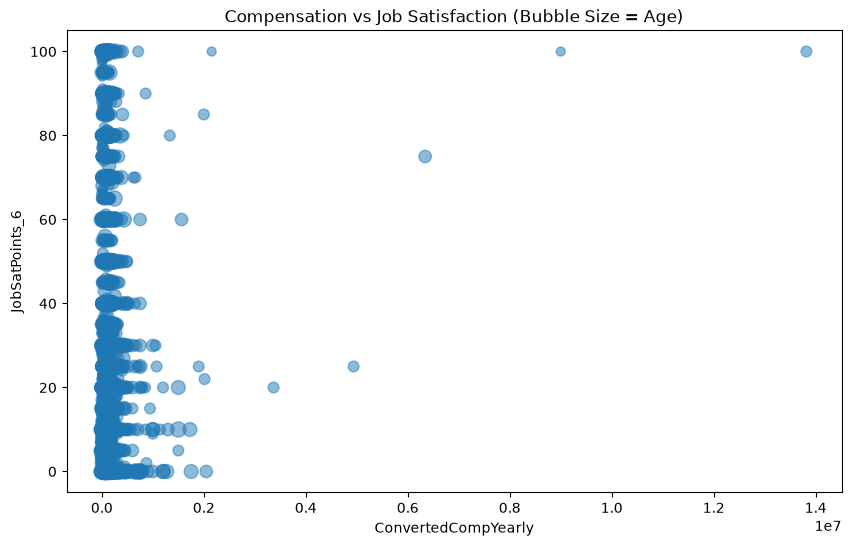

In [11]:
QUERY = """
SELECT Age, ConvertedCompYearly, JobSatPoints_6
FROM main
WHERE Age IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_bubble = pd.read_sql_query(QUERY, conn)

df_bubble['AgeNumeric'] = df_bubble['Age'].map(age_mapping)

plt.figure(figsize=(10,6))

plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=df_bubble['AgeNumeric'] * 2,
    alpha=0.5
)

plt.title('Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_6')

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


<Axes: xlabel='Language', ylabel='JobSatPoints_6'>

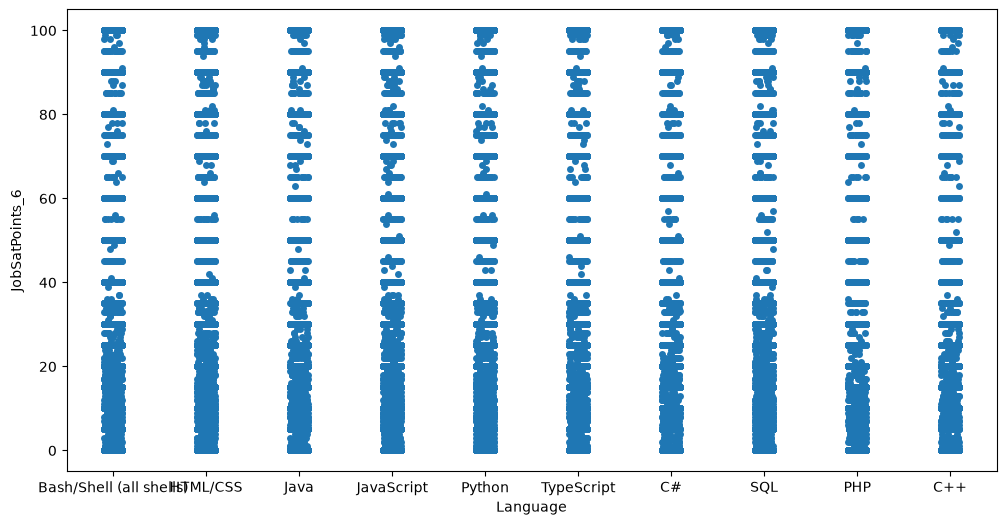

In [13]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

QUERY = """
SELECT LanguageHaveWorkedWith, JobSatPoints_6
FROM main
WHERE LanguageHaveWorkedWith IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_lang = pd.read_sql_query(QUERY, conn)

# Expand language lists
rows = []

for _, row in df_lang.iterrows():
    languages = str(row['LanguageHaveWorkedWith']).split(';')
    for lang in languages:
        rows.append([lang, row['JobSatPoints_6']])

lang_df = pd.DataFrame(rows, columns=['Language', 'JobSatPoints_6'])

# Top 10 languages
top_languages = lang_df['Language'].value_counts().head(10).index

lang_df = lang_df[lang_df['Language'].isin(top_languages)]

plt.figure(figsize=(12,6))

sns.stripplot(
    data=lang_df,
    x='Language',
    y='JobSatPoints_6')

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


<Figure size 1200x600 with 0 Axes>

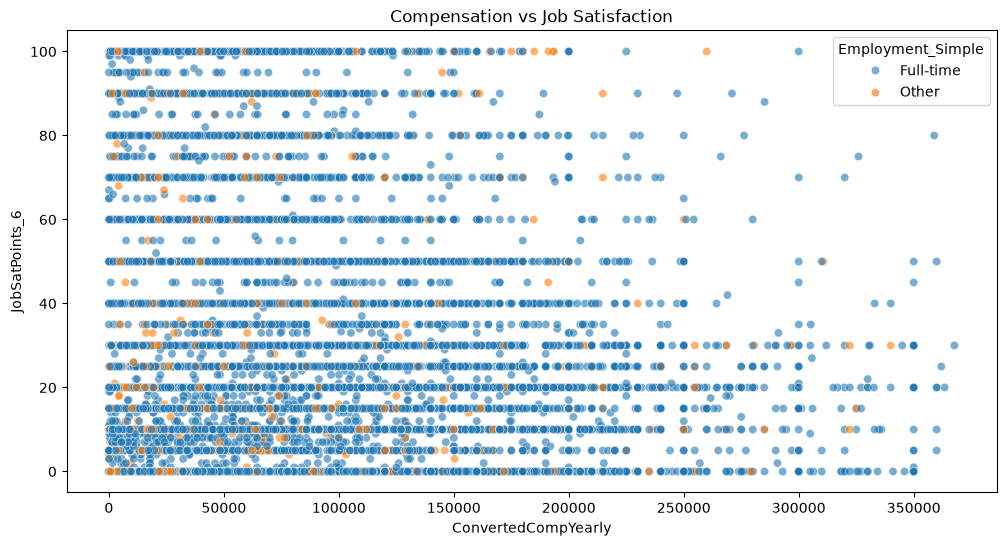

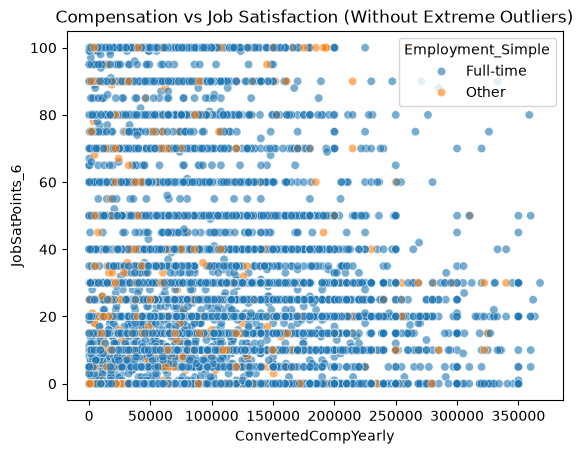

In [17]:
upper_limit = df_emp['ConvertedCompYearly'].quantile(0.99)

df_emp_filtered = df_emp[
    df_emp['ConvertedCompYearly'] <= upper_limit
]

plt.figure(figsize=(12,6))

# Create simplified employment categories
df_emp['Employment_Simple'] = df_emp['Employment'].apply(
    lambda x: 'Full-time'
    if 'Employed, full-time' in str(x)
    else 'Other'
)

# Remove extreme compensation outliers
upper_limit = df_emp['ConvertedCompYearly'].quantile(0.99)

df_emp_filtered = df_emp[
    df_emp['ConvertedCompYearly'] <= upper_limit
]

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_emp_filtered,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    hue='Employment_Simple',
    alpha=0.6
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_6')

plt.show()

sns.scatterplot(
    data=df_emp_filtered,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    hue='Employment_Simple',
    alpha=0.6
)

plt.title('Compensation vs Job Satisfaction (Without Extreme Outliers)')
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


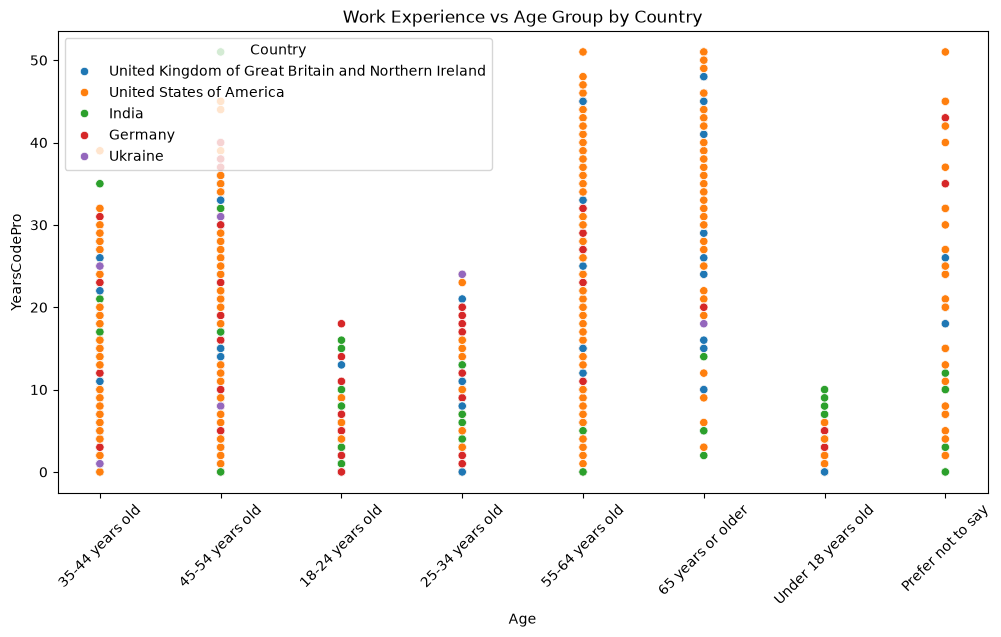

In [18]:
QUERY = """
SELECT Age,
       YearsCodePro,
       Country
FROM main
WHERE Age IS NOT NULL
AND YearsCodePro IS NOT NULL
AND Country IS NOT NULL
"""

df_country = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro
df_country['YearsCodePro'] = df_country['YearsCodePro'].replace({
    'Less than 1 year': '0',
    'More than 50 years': '51'
})

df_country['YearsCodePro'] = pd.to_numeric(
    df_country['YearsCodePro'],
    errors='coerce'
)

# Top 5 countries
top_countries = df_country['Country'].value_counts().head(5).index

df_country = df_country[
    df_country['Country'].isin(top_countries)
]

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_country,
    x='Age',
    y='YearsCodePro',
    hue='Country'
)

plt.xticks(rotation=45)
plt.title('Work Experience vs Age Group by Country')

plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
